In [2]:
from pathlib import Path
import xarray as xr
import pandas as pd
import numpy as np

data_dir = Path(r"D:\INCOIS\Data_Float_Fixed")
phyto_list = []



In [3]:
files = sorted(data_dir.glob("*.nc"))

for i, file in enumerate(files):

    ds = xr.open_dataset(file)

    kerala = ds.sel(
        lat=slice(12, 8),
        lon=slice(73, 77)
    )

    # Mask where either input is NaN
    nan_mask = kerala["CHLOR_A"].isnull() | kerala["PhytoID"].isnull()

    phytobloom = xr.where(
        nan_mask,
        np.nan,
        xr.where(
            (kerala["PhytoID"] == 1) &
            (kerala["CHLOR_A"] > 1),

            1,

            xr.where(
                (kerala["PhytoID"] == 2) &
                (kerala["CHLOR_A"] > 1),

                2,

                0
            )
        )
    )

    date = pd.to_datetime(
        file.name[1:9],
        format="%Y%m%d"
    )

    phytobloom = phytobloom.expand_dims(
        time=[date]
    )

    phyto_list.append(phytobloom)

    ds.close()

    if (i + 1) % 100 == 0:
        print(f"{i+1}/{len(files)}")

100/8344
200/8344
300/8344
400/8344
500/8344
600/8344
700/8344
800/8344
900/8344
1000/8344
1100/8344
1200/8344
1300/8344
1400/8344
1500/8344
1600/8344
1700/8344
1800/8344
1900/8344
2000/8344
2100/8344
2200/8344
2300/8344
2400/8344
2500/8344
2600/8344
2700/8344
2800/8344
2900/8344
3000/8344
3100/8344
3200/8344
3300/8344
3400/8344
3500/8344
3600/8344
3700/8344
3800/8344
3900/8344
4000/8344
4100/8344
4200/8344
4300/8344
4400/8344
4500/8344
4600/8344
4700/8344
4800/8344
4900/8344
5000/8344
5100/8344
5200/8344
5300/8344
5400/8344
5500/8344
5600/8344
5700/8344
5800/8344
5900/8344
6000/8344
6100/8344
6200/8344
6300/8344
6400/8344
6500/8344
6600/8344
6700/8344
6800/8344
6900/8344
7000/8344
7100/8344
7200/8344
7300/8344
7400/8344
7500/8344
7600/8344
7700/8344
7800/8344
7900/8344
8000/8344
8100/8344
8200/8344
8300/8344


In [4]:
phyto = xr.concat(
    phyto_list,
    dim="time"
)

phyto_ds = phyto.to_dataset(
    name="PHYTOBLOOM"
)

print(phyto_ds)

<xarray.Dataset> Size: 615MB
Dimensions:     (time: 8344, lon: 96, lat: 96)
Coordinates:
  * time        (time) datetime64[us] 67kB 2003-01-01 2003-01-02 ... 2025-11-30
  * lon         (lon) float32 384B 73.02 73.06 73.1 73.15 ... 76.9 76.94 76.98
  * lat         (lat) float32 384B 11.98 11.94 11.9 11.85 ... 8.104 8.062 8.021
Data variables:
    PHYTOBLOOM  (time, lat, lon) float64 615MB 0.0 0.0 0.0 0.0 ... nan nan nan


In [5]:
phyto_ds.to_netcdf(
    r"D:\INCOIS\PHYTOBLOOM_KERALA.nc"
)

In [6]:
import xarray as xr, numpy as np

test = xr.open_dataset(
    r"D:\INCOIS\PHYTOBLOOM_KERALA.nc"
)

print(
    np.unique(
        test["PHYTOBLOOM"]
        .isel(time=0)
        .values
    )
)

[ 0.  1.  2. nan]


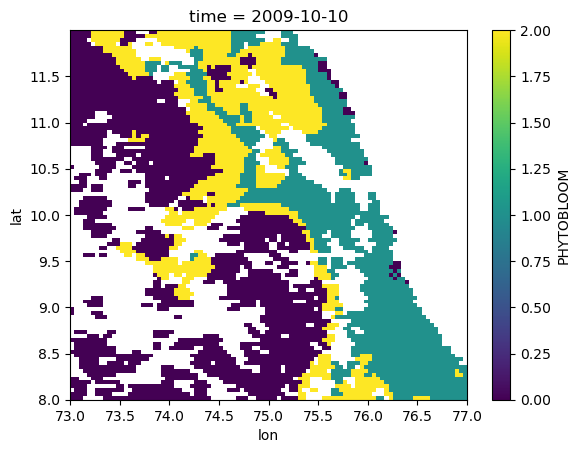

In [7]:
test["PHYTOBLOOM"].sel(time="2009-10-10").plot()

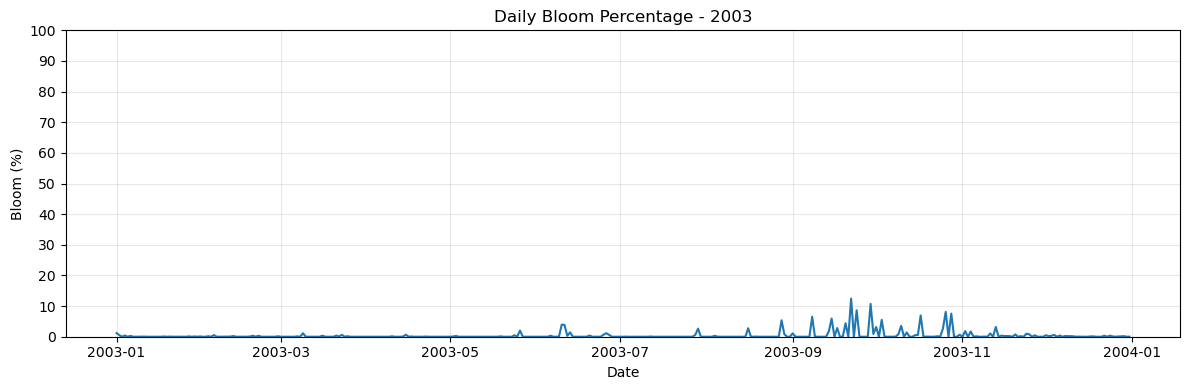

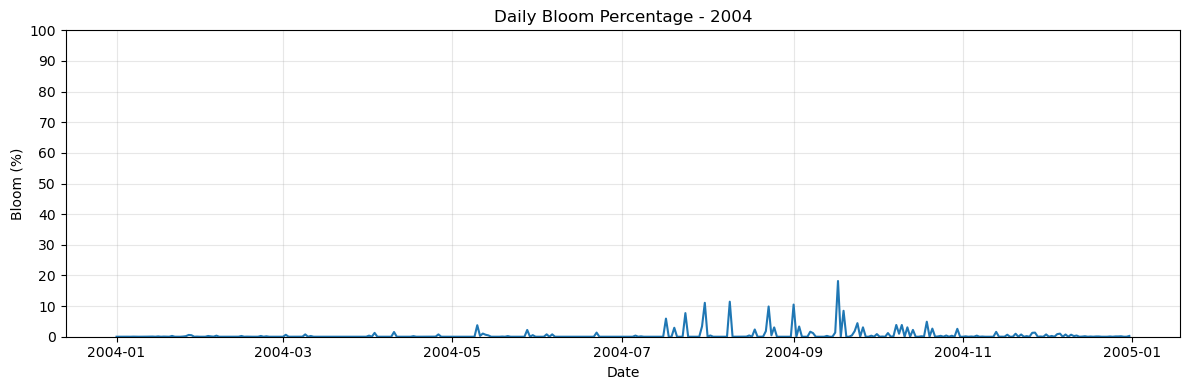

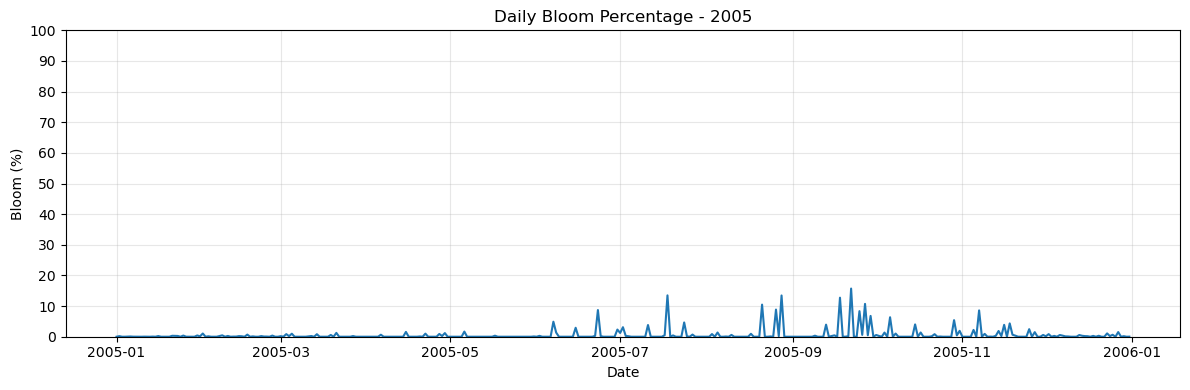

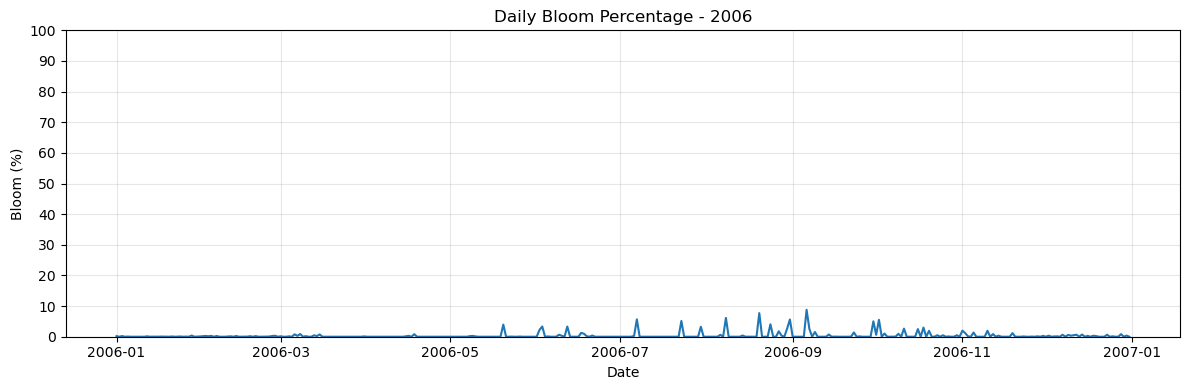

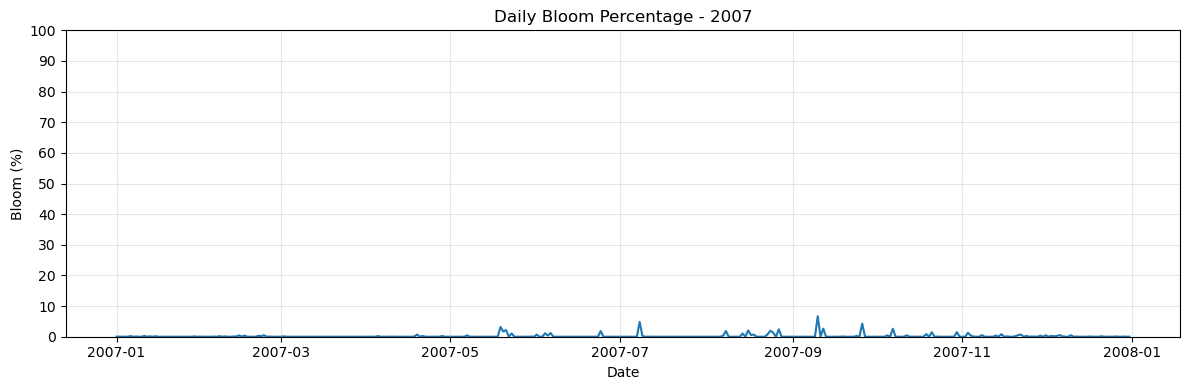

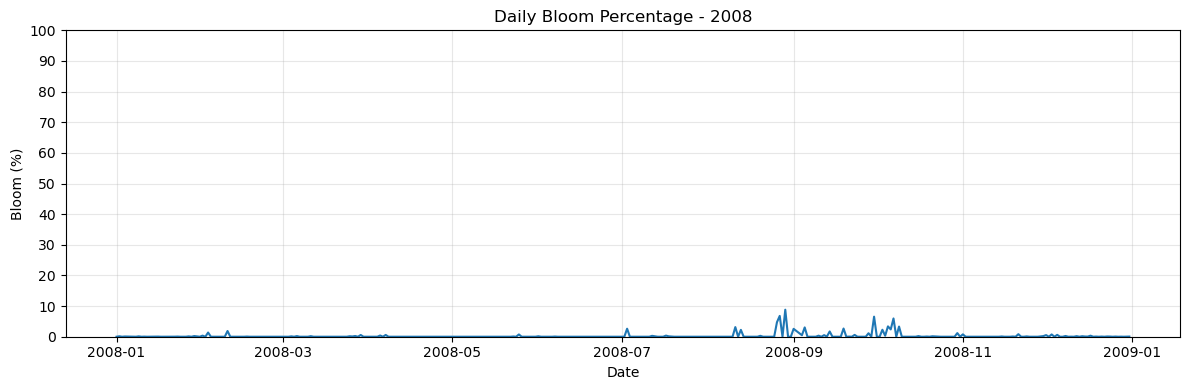

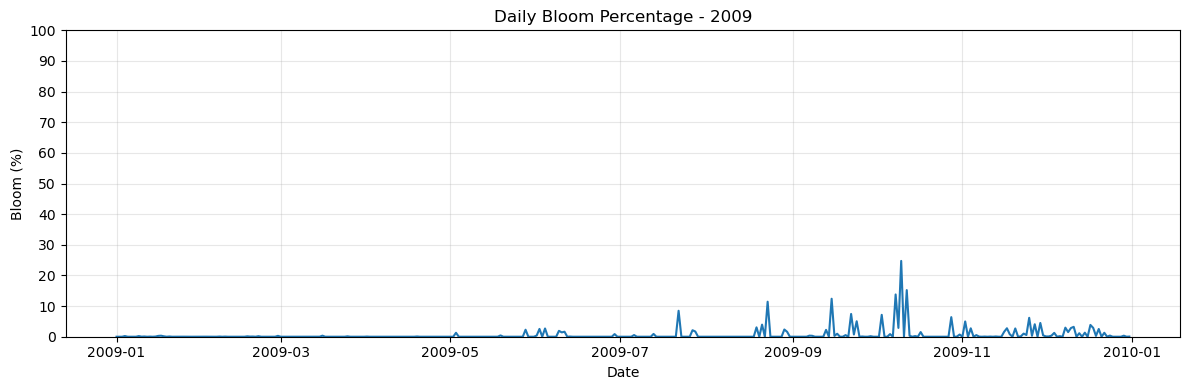

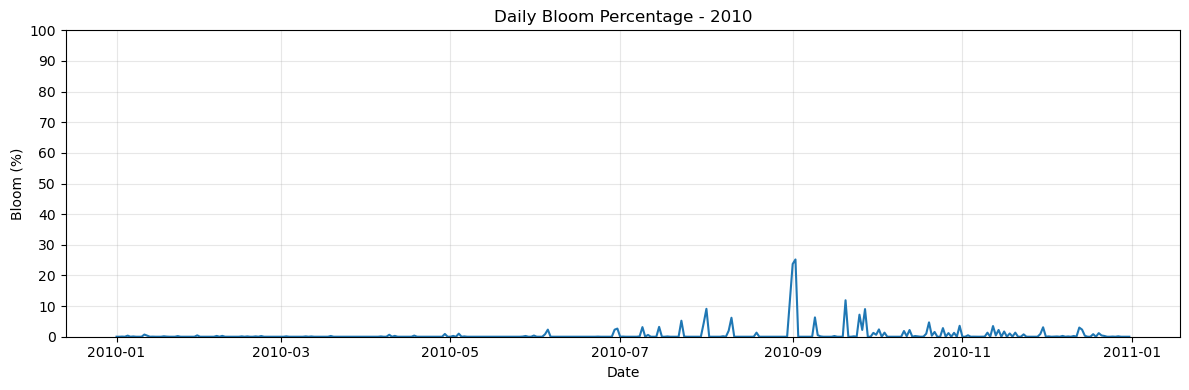

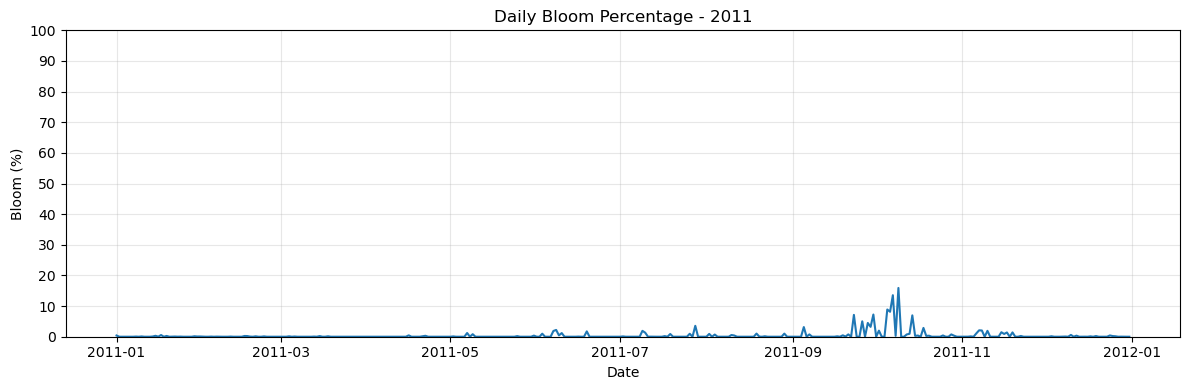

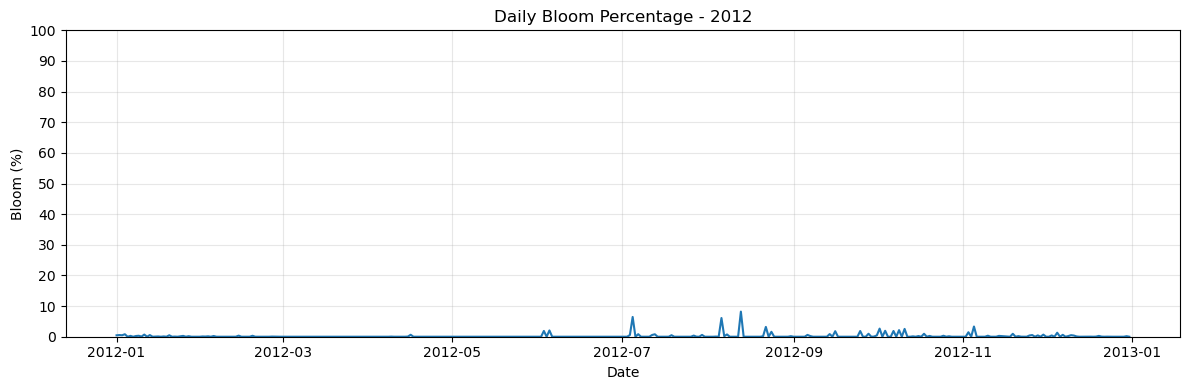

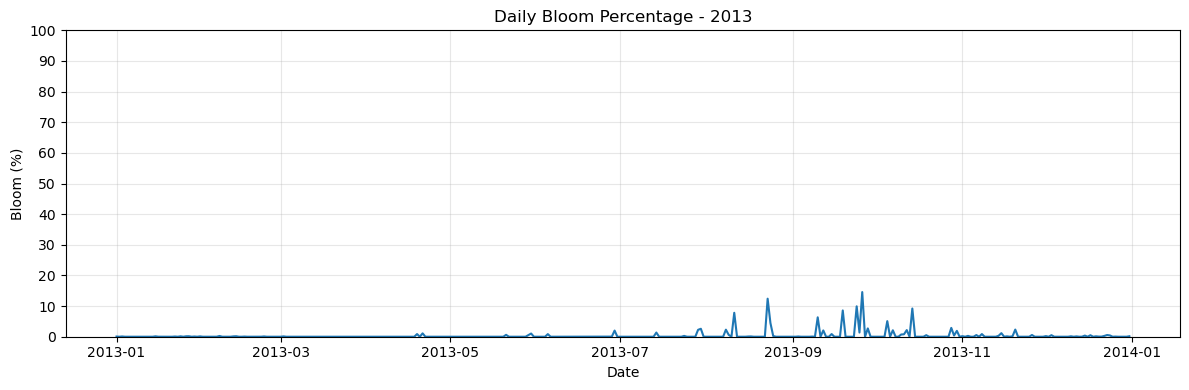

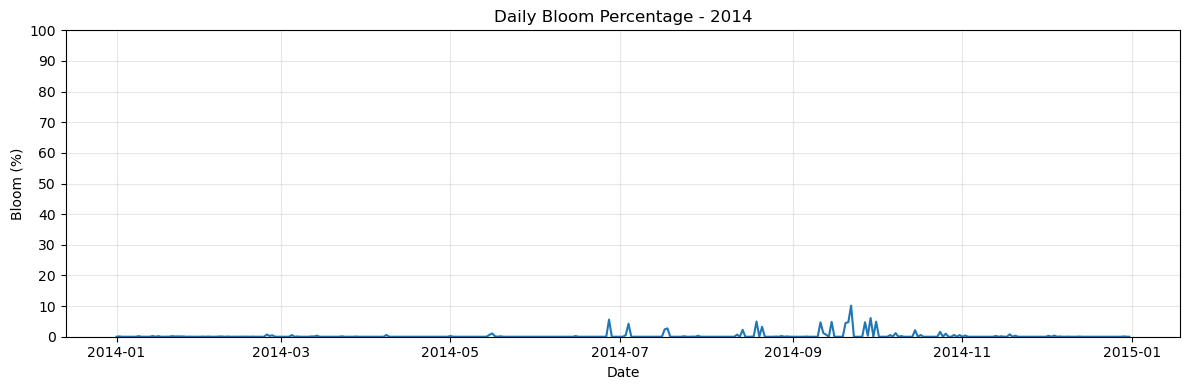

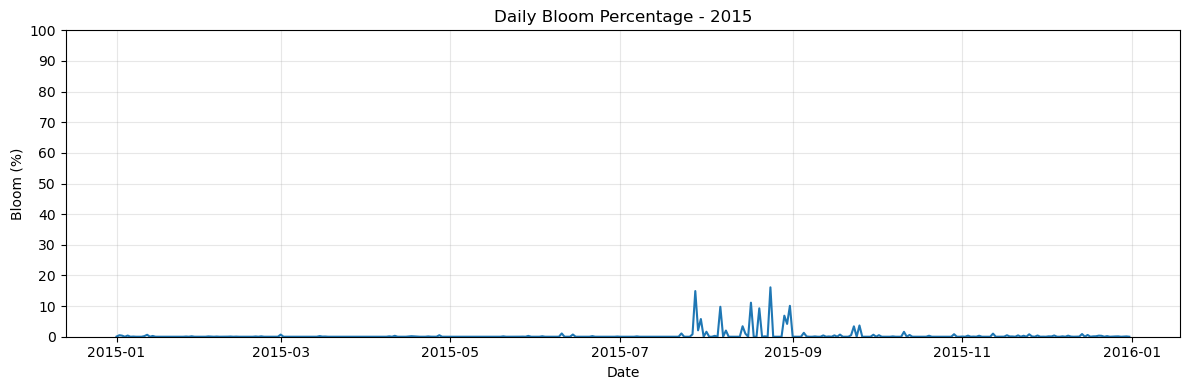

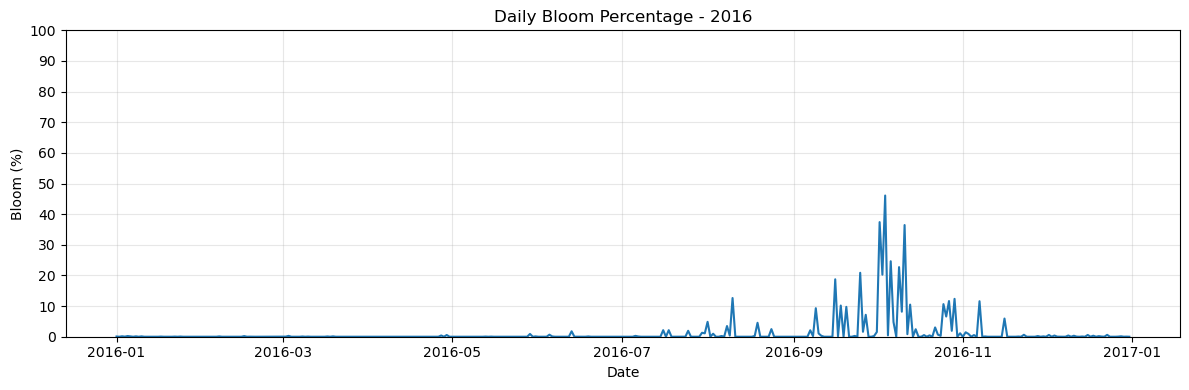

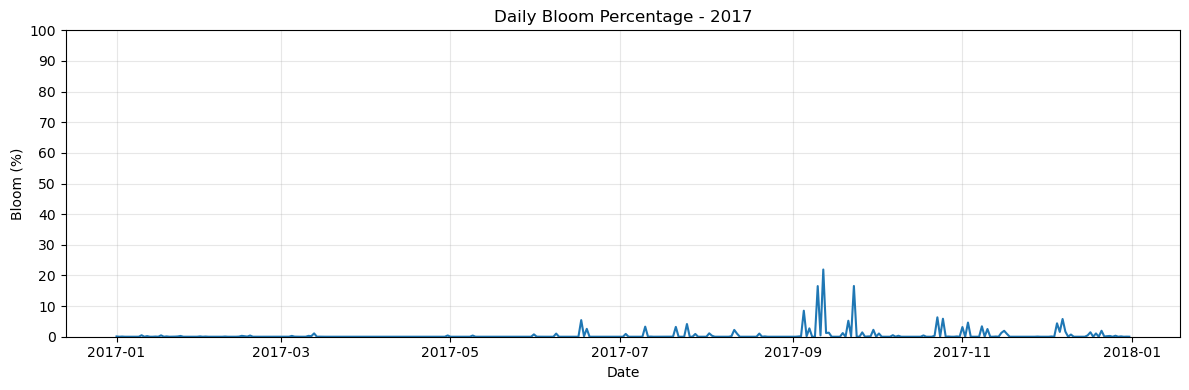

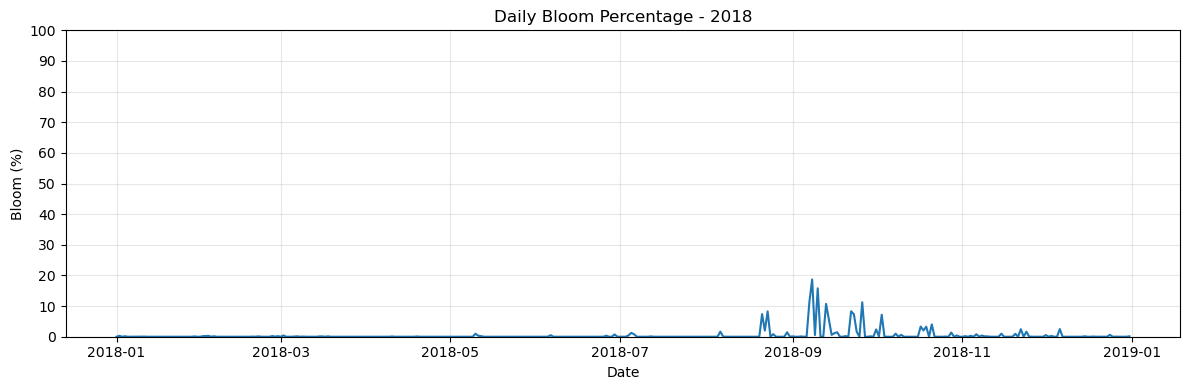

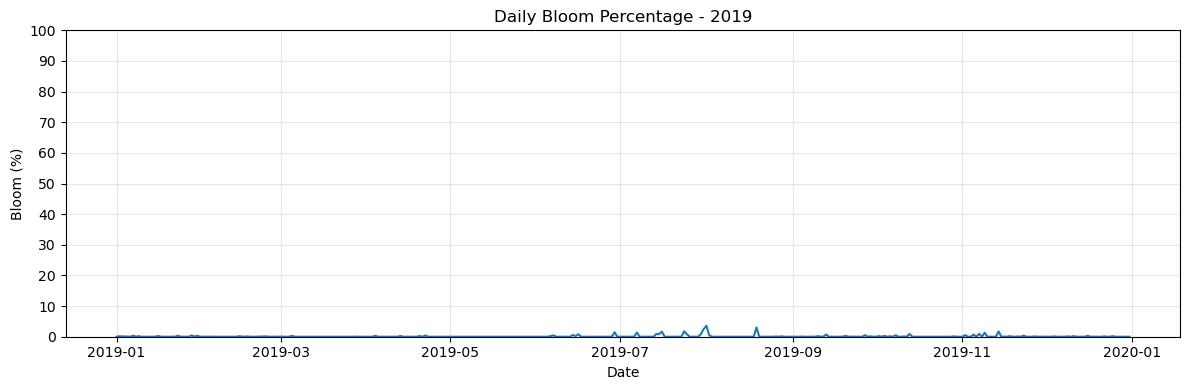

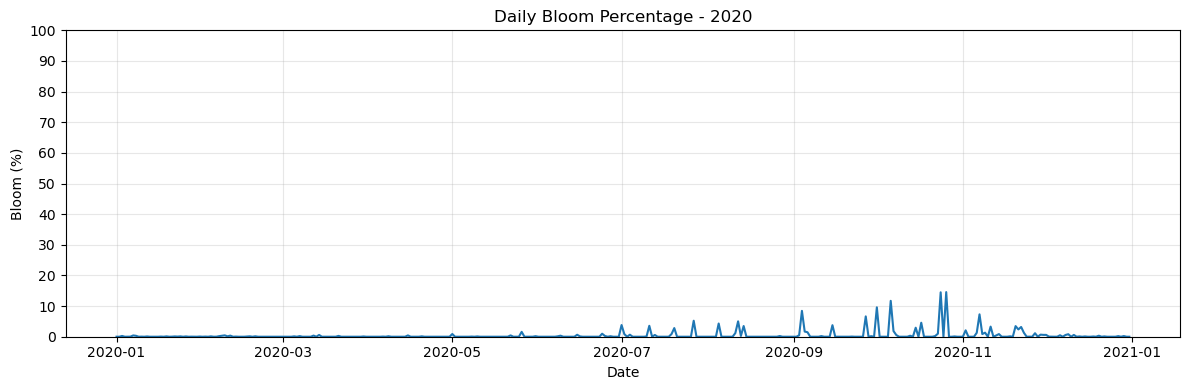

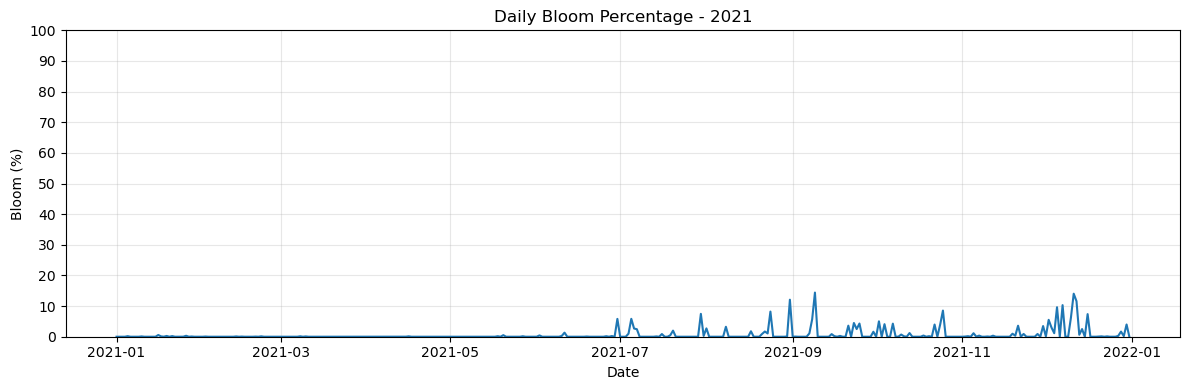

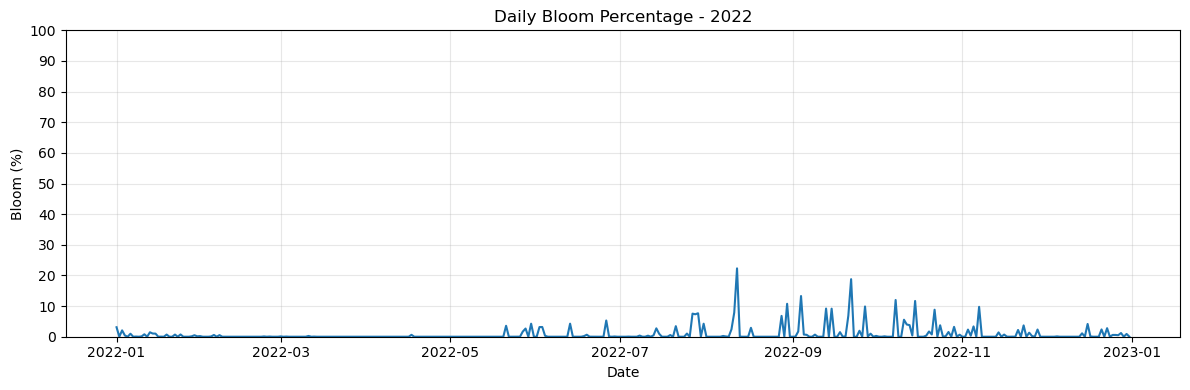

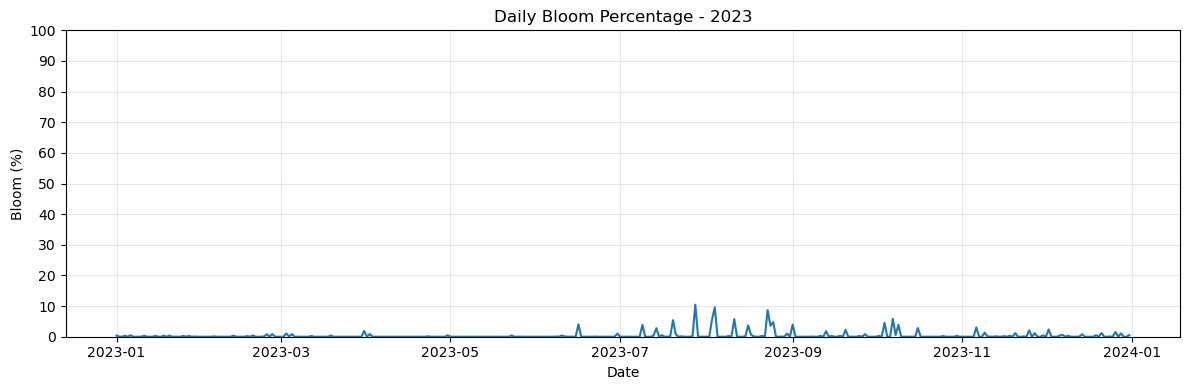

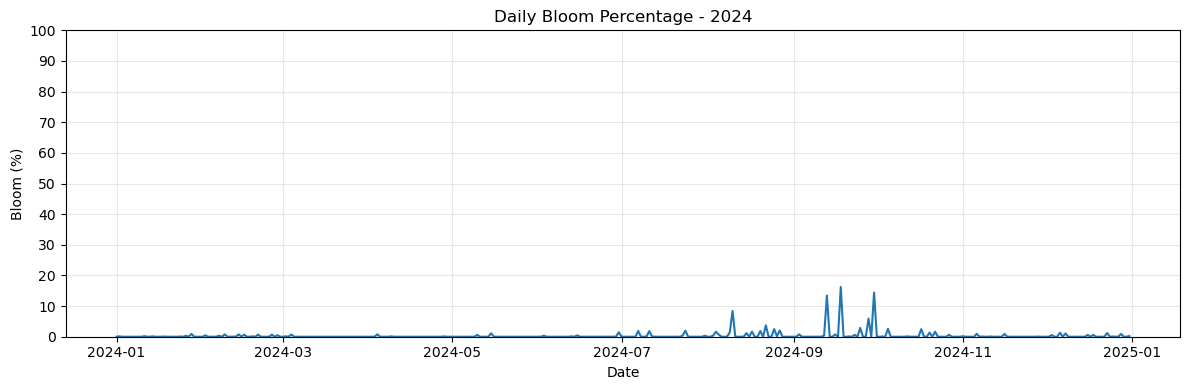

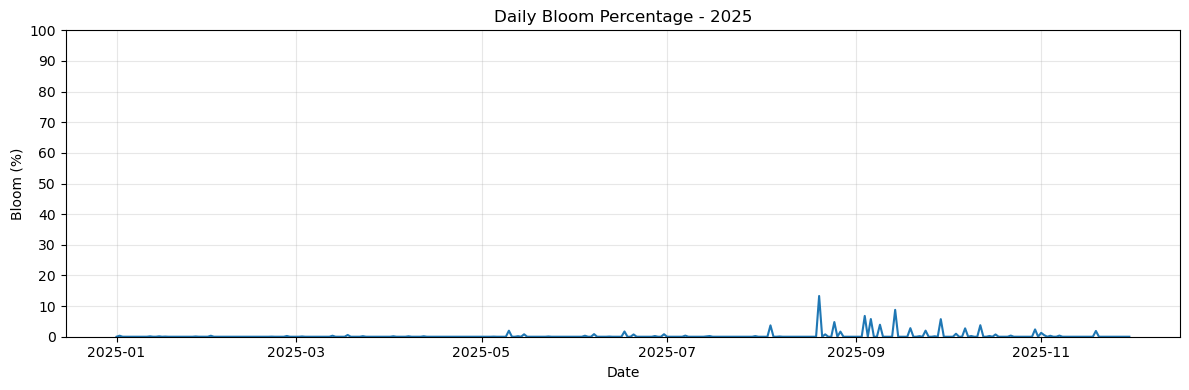

In [21]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

ds = xr.open_dataset(r"D:\INCOIS\PHYTOBLOOM_KERALA.nc")

# Total number of pixels in the Kerala region
total_pixels = ds.sizes["lat"] * ds.sizes["lon"]

# Daily bloom percentage
bloom_percent = (
    (ds["PHYTOBLOOM"] > 0).sum(dim=("lat", "lon")) / total_pixels
) * 100

years = np.unique(bloom_percent.time.dt.year)

for year in years:

    yearly = bloom_percent.sel(time=str(year))

    plt.figure(figsize=(12, 4))
    plt.plot(yearly.time.values, yearly.values, lw=1.5)

    plt.title(f"Daily Bloom Percentage - {year}")
    plt.xlabel("Date")
    plt.ylabel("Bloom (%)")

    # Same y-axis for every graph
    plt.ylim(0, 100)
    plt.yticks(np.arange(0, 101, 10))

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [13]:
d=xr.open_dataset("D:/INCOIS/cmems_1997_2025_WAS.nc")
d

<xarray.Dataset> Size: 31GB
Dimensions:    (time: 10592, latitude: 253, longitude: 241, depth: 1)
Coordinates:
  * time       (time) datetime64[ns] 85kB 1997-01-01 1997-01-02 ... 2025-12-31
  * latitude   (latitude) float32 1kB 5.0 5.083 5.167 5.25 ... 25.83 25.92 26.0
  * longitude  (longitude) float32 964B 45.0 45.08 45.17 ... 64.83 64.92 65.0
  * depth      (depth) float32 4B 0.494
Data variables:
    mlotst     (time, latitude, longitude) float64 5GB ...
    so         (time, depth, latitude, longitude) float64 5GB ...
    thetao     (time, depth, latitude, longitude) float64 5GB ...
    uo         (time, depth, latitude, longitude) float64 5GB ...
    vo         (time, depth, latitude, longitude) float64 5GB ...
    zos        (time, latitude, longitude) float64 5GB ...
Attributes: (12/25)
    Conventions:               CF-1.4
    bulletin_date:             2021-07-07 00:00:00
    bulletin_type:             operational
    comment:                   CMEMS product
    domain_name:               GL12
    easting:                   longitude
    ...                        ...
    references:                http://www.mercator-ocean.fr
    source:                    MERCATOR GLORYS12V1
    title:                     daily mean fields from Global Ocean Physics An...
    z_max:                     5727.9169921875
    z_min:                     0.49402499198913574
    copernicusmarine_version:  2.3.0